#**Séries temporais do sensor *Wide-Field Imager* (WFI) para mapeamento de áreas queimadas no Cerrado**

###**Transformação em séries temporais tabulares [2/5]**

No *post* anterior (series_temporais/01_decomposicao_series_temporais.ipynb) vimos como decompor uma série temporal (ideal) em tendência, sazonalidade e resíduos. Mas, antes disso, em problemas reais (*real-world datasets*), há a etapa de **preparação dos dados**. O *dataset* tabular do sensor WFI contém as datas em que áreas queimadas no Parque Nacional da Chapada dos Veadeiros foram identificadas entre 2020 e 2022 e rotuladas manualmente. As datas são esparsas (estão distribuídas em três colunas no *DataFrame*) e dias sem detecções não possuem observações.

**O desafio:** como encontrar padrões temporais quando a série temporal é incompleta? A solução é **transformar** esses registros em uma série temporal contínua, contabilizando **diariamente** cada célula (linha do *DataFrame*) como 'queimado' ou 'não queimado'. Nesse *notebook* utilizaremos as células da grade como unidades de análise, mas podiam ser pixels (como *rasters* de produtos de áreas queimadas) ou pontos como focos de calor (vetores com datas das detecções, como os disponibilizados pelo BDQueimadas/INPE).

**1) *Download* e preparação dos dados**

Antes de iniciarmos a análise, precisamos obter a base de dados. O conjunto utilizado neste exercício está disponível publicamente e reúne os registros do sensor WFI entre 2020 e 2022... Convertamos o arquivo CSV para Parquet, um formato mais eficiente para leitura e manipulação de grandes volumes de dados.

**Observação**: esse *dataset* contém diversas outras colunas, mas nesse exercício nos focaremos nas colunas que possuem as anotações das datas das áreas queimadas. Para entender melhor o *dataset*, consulte: https://doi.org/10.1080/20964471.2025.2463731

In [1]:
# ============================================
# FUNÇÕES AUXILIARES
# ============================================

import requests
from tqdm.auto import tqdm

def download(url: str, output: str) -> None:
    response = requests.get(url, stream=True)
    response.raise_for_status()

    total_size = int(response.headers.get("content-length", 0))

    with open(output, "wb") as f, tqdm(
        total=total_size,
        unit="B",
        unit_scale=True,
        desc=output.split("/")[-1],
    ) as pbar:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            f.write(chunk)
            pbar.update(len(chunk))

# ============================================
# DOWNLOAD E PREPARAÇÃO DOS DADOS
# ============================================

import pandas as pd # trabalha com dataframes
import os

# ----------------------------------------------------------------------------
# CAMINHOS E URLS
# ----------------------------------------------------------------------------

CSV_URL = "https://download.scidb.cn/download?fileId=e22fe8b8fa7b696516664d76a42ac2fe&path=/V4/Dataset_WFI.csv&fileName=Dataset_WFI.csv" # link do dataset no repositório ScienceDB

# Criar diretório no armazenamento temporário do Colab
BASE_DIR = "/content/ScienceDB/Dataset"
csv_path = os.path.join(BASE_DIR, "Dataset_WFI.csv")
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

# Criar diretório se não existir
os.makedirs(BASE_DIR, exist_ok=True)

# ----------------------------------------------------------------------------
# DOWNLOAD E CONVERSÃO DE CSV PARA PARQUET
# ----------------------------------------------------------------------------

if not os.path.exists(parquet_path):
    # Baixar CSV se necessário
    if not os.path.exists(csv_path):
        download(CSV_URL, csv_path)
    else:
        print(f"✓ CSV já existe: {csv_path}")

    # Converter para Parquet (formato mais eficiente)
    print("Convertendo CSV para Parquet...")
    df = pd.read_csv(csv_path)
    df.to_parquet(parquet_path, compression="snappy")

    # Liberar memória e limpar
    del df
    os.remove(csv_path)
    print(f"✓ Parquet salvo: {parquet_path}")
    print(f"✓ CSV removido: {csv_path}") # como o csv é pesado, removemos ele após a conversão para Parquet
else:
    print(f"✓ Parquet já existe: {parquet_path}")

print("\n✓ Arquivo de dados pronto!")

✓ Parquet já existe: /content/ScienceDB/Dataset/Dataset_WFI.parquet

✓ Arquivo de dados pronto!


**2) Carregando os dados e identificando as colunas de interesse**

Com o arquivo Parquet preparado, podemos carregá-lo e examinar as colunas com as datas das áreas queimadas. O *dataset* possui três colunas com as datas anotadas: uma coluna para cada ano (2020, 2021 e 2022):

| Coluna | Descrição |
|--------|-----------|
| `date_20` | Datas de queimada no ano de 2020 |
| `date_21` | Datas de queimada no ano de 2021 |
| `date_22` | Datas de queimada no ano de 2022 |

Cada registro representa uma célula espacial de 500 m × 500 m. Quando uma área queimada é detectada, a data da imagem é registrada na coluna correspondente. Caso contrário, o valor é ausente (*None*). Essas colunas servirão de base para construirmos a série temporal contínua nos próximos passos (observe que ainda não vamos analisar as informações espectrais do *dataset*, mas **apenas** as três **colunas** com as **datas**).

In [2]:
# ============================================
# CARREGAMENTO DOS DADOS E EXTRAÇÃO DAS DATAS DE QUEIMADA
# ============================================

import os
import pandas as pd

# ----------------------------------------------------------------------------
# CARREGAR ARQUIVO PARQUET
# ----------------------------------------------------------------------------

BASE_DIR = "/content/ScienceDB/Dataset"
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

print("Carregando arquivo Parquet...")
df = pd.read_parquet(parquet_path)

print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]} colunas")

# ----------------------------------------------------------------------------
# EXTRAIR COLUNAS DE DATAS
# ----------------------------------------------------------------------------

date_columns = ["date_20", "date_21", "date_22"]
burn_dates = df[date_columns].copy()

# ----------------------------------------------------------------------------
# EXIBIR ESTRUTURA DO DATASET
# ----------------------------------------------------------------------------

print("\n" + "=" * 50)
print("VISÃO GERAL DAS COLUNAS DE DATAS")
print("=" * 50)
burn_dates.info()

print("\n" + "=" * 50)
print("VALORES NULOS POR COLUNA")
print("=" * 50)
print(burn_dates.isnull().sum())

# ----------------------------------------------------------------------------
# EXIBIR AMOSTRA DE DATAS VÁLIDAS
# ----------------------------------------------------------------------------

print("\n" + "=" * 50)
print("AMOSTRA DE DATAS NÃO NULAS")
print("=" * 50)

for column in date_columns:
    valid_dates = burn_dates[column].dropna()
    print(f"\n{column}")
    if valid_dates.empty:
        print("Nenhuma data válida encontrada.")
    else:
        print(valid_dates.head().tolist())

Carregando arquivo Parquet...
✓ Dataset carregado: 38,957 linhas, 9862 colunas

VISÃO GERAL DAS COLUNAS DE DATAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38957 entries, 0 to 38956
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   date_20  4695 non-null   object
 1   date_21  4910 non-null   object
 2   date_22  5204 non-null   object
dtypes: object(3)
memory usage: 913.2+ KB

VALORES NULOS POR COLUNA
date_20    34262
date_21    34047
date_22    33753
dtype: int64

AMOSTRA DE DATAS NÃO NULAS

date_20
['05-10-20', '05-10-20', '05-10-20', '05-10-20', '25-08-20']

date_21
['10-06-21', '10-06-21', '10-06-21', '10-06-21', '07-10-21']

date_22
['13-10-22', '12-10-22', '12-10-22', '12-10-22', '12-10-22']


Os *prints* apresentam uma análise exploratória das colunas **date_20**, **date_21** e **date_22** depois do carregamento do arquivo Parquet. O conjunto de dados possui **38.957 registros** (células representadas nas linhas) e as colunas estão armazenadas no formato *object* (texto).

Perceba que existem muitos valores nulos em todas elas, o que indica que as datas estão disponíveis apenas para parte dos registros (somente as células que foram identificas como contendo áreas queimadas quando sobrepostas às imagens de satélites que originaram o *DataFrame*... as imagens também estão disponíveis no ScienceDB, em formato .tif). A amostra dos valores mostra que as datas seguem o padrão dd-mm-aa.

**3) De datas esparsas a séries temporais contínuas**

Agora vem a etapa central da transformação temporal. Temos três colunas com datas, mas cada uma registra apenas o dia em que a queimada foi identificada. Para analisarmos esses dados como uma série temporal, precisamos convertê-los em uma representação contínua no tempo.

O raciocínio é simples: para cada célula de 500 m x 500 m (ou seja, cada linha) anotada como área queimada, criamos uma sequência diária de ocorrências. O dia da detecção recebe valor 1 (presente) e os demais dias recebem o valor 0 (ausente). Assim, cada ano é representado por uma série de 365 valores (ou 366, se bissexto -> 2020 foi bissexto).

In [3]:
# ============================================
# TRANSFORMAÇÃO EM SÉRIE TEMPORAL CONTÍNUA
# ============================================

import os
import calendar
import pandas as pd

# ----------------------------------------------------------------------------
# CARREGAR ARQUIVO PARQUET
# ----------------------------------------------------------------------------

BASE_DIR = "/content/ScienceDB/Dataset"
parquet_path = os.path.join(BASE_DIR, "Dataset_WFI.parquet")

df = pd.read_parquet(parquet_path)

print(f"✓ Dataset carregado: {df.shape[0]:,} linhas, {df.shape[1]:,} colunas")

# ----------------------------------------------------------------------------
# FUNÇÃO: CONVERTER COLUNA DE DATAS EM SÉRIE TEMPORAL DIÁRIA
# ----------------------------------------------------------------------------

def date_column_to_series(date_col: pd.Series, year: int) -> pd.Series:
    """
    Converte uma coluna de datas de queimada em uma série temporal diária.

    Parâmetros
    ----------
    date_col : pd.Series
        Coluna contendo datas no formato 'DD-MM-YY'.
    year : int
        Ano associado à coluna.

    Retorno
    -------
    pd.Series
        Série diária indexada pelo dia do ano.
        Cada valor representa o número de detecções registradas naquele dia.
    """

    # Número de dias no ano (365 ou 366)
    n_days = 366 if calendar.isleap(year) else 365

    # Remover valores ausentes
    valid_dates = date_col.dropna()

    # Se não houver detecções, retornar uma série de zeros
    if valid_dates.empty:
        return pd.Series(0, index=range(1, n_days + 1), dtype=int)

    # Converter strings para datetime
    dates = pd.to_datetime(valid_dates, format="%d-%m-%y") # é necessário converter os valores (textuais) nas colunas em datetime

    # Extrair o dia do ano (1...365/366)
    day_of_year = dates.dt.dayofyear

    # Contar o número de detecções para cada dia (para usar no eixo y)
    daily_counts = (
        day_of_year
        .value_counts()
        .sort_index()
        .reindex(range(1, n_days + 1), fill_value=0)
    )

    daily_counts.name = str(year)

    return daily_counts

# ----------------------------------------------------------------------------
# CONSTRUIR SÉRIE TEMPORAL DIÁRIA
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("TRANSFORMANDO DATAS EM SÉRIE TEMPORAL DIÁRIA")
print("=" * 60)

daily_series = {}

date_mapping = {
    "date_20": 2020,
    "date_21": 2021,
    "date_22": 2022,
}

for column, year in date_mapping.items():

    print(f"\nProcessando {column}...")

    series = date_column_to_series(df[column], year)

    daily_series[str(year)] = series

    print(f"  ✓ Total de detecções: {int(series.sum()):,}")
    print(f"  ✓ Dias com detecções: {(series > 0).sum()}")
    print(f"  ✓ Máximo de detecções em um dia: {series.max()}")

# ----------------------------------------------------------------------------
# CRIAR DATAFRAME
# ----------------------------------------------------------------------------

df_daily = pd.DataFrame(daily_series)
df_daily.index.name = "DayOfYear"

✓ Dataset carregado: 38,957 linhas, 9,862 colunas

TRANSFORMANDO DATAS EM SÉRIE TEMPORAL DIÁRIA

Processando date_20...
  ✓ Total de detecções: 4,695
  ✓ Dias com detecções: 35
  ✓ Máximo de detecções em um dia: 1750

Processando date_21...
  ✓ Total de detecções: 4,910
  ✓ Dias com detecções: 59
  ✓ Máximo de detecções em um dia: 605

Processando date_22...
  ✓ Total de detecções: 5,204
  ✓ Dias com detecções: 79
  ✓ Máximo de detecções em um dia: 673


**4) Visualizando temporalmente as ocorrências**

Agora podemos visualizar a série temporal contínua e explorar, visualmente, alguns padrões iniciais. O eixo x representa o dia do ano (três anos de análise), enquanto o eixo y indica o número de células (entendidas aqui como detecções) rotuladas como área queimada.

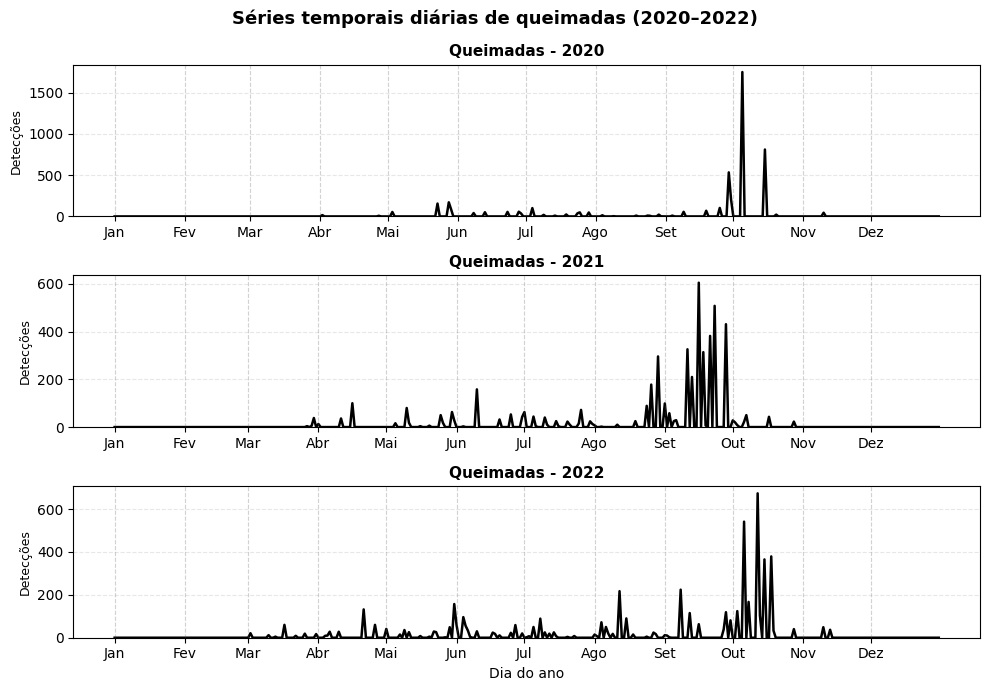

In [4]:
# ============================================
# VISUALIZAÇÃO DA SÉRIE TEMPORAL DIÁRIA
# ============================================

import calendar
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------
# GRÁFICO DA SÉRIE DIÁRIA PARA TODOS OS ANOS
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=False)

# Rótulos dos meses
month_labels = [
    "Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
    "Jul", "Ago", "Set", "Out", "Nov", "Dez"
]

for ax, (year, series) in zip(axes, df_daily.items()):

    # Gráfico das detecções diárias
    ax.plot(
        series.index,
        series.values,
        color="black",
        linewidth=1.8
    )

    # Formatação do gráfico
    ax.set_title(f"Queimadas - {year}", fontsize=11, fontweight="bold")
    ax.set_ylabel("Detecções", fontsize=9)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3, linestyle="--")

    # ------------------------------------------------------------
    # Calcular o primeiro dia de cada mês
    # ------------------------------------------------------------
    month_starts = []
    day = 1

    for month in range(1, 13):
        month_starts.append(day)
        day += calendar.monthrange(int(year), month)[1]

    # Linhas verticais no início de cada mês
    for start_day in month_starts:
        ax.axvline(
            start_day,
            color="gray",
            linestyle="--",
            linewidth=0.8,
            alpha=0.2
        )

    # Configurar eixo X
    ax.set_xticks(month_starts)
    ax.set_xticklabels(month_labels)

# Rótulo apenas no subplot inferior
axes[-1].set_xlabel("Dia do ano", fontsize=10)

plt.suptitle(
    "Séries temporais diárias de queimadas (2020–2022)",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

**5) Decompondo as séries**

Decomporemos as séries temporais (cada célula tem uma) de 2020 a 2022... **Mas, por que utilizar a série de 2020 a 2022 e não cada ano individualmente?**

A decomposição sazonal com '*seasonal_decompose*' requer, idealmente, mais de um ciclo completo para estimar a sazonalidade. Como um único ano contém apenas um ciclo anual, a série concatenada com 1096 observações diárias (2020–2022) fornece dados para uma decomposição mais coerente (mais anos disponíveis na série temporal -> melhores resultados).

Essa mesma análise também poderia ser feita em outras escalas de tempo, como mensal, bimestral ou trimestral, dependendo do comportamento do fenômeno estudado. No caso das áreas queimadas, faz sentido observar os meses mais secos, pois no Cerrado a maior concentração de eventos costuma ocorrer entre maio e setembro (um ciclo anual permite a identificação de dois comportamentos principais: um com **poucas áreas queimadas na estação chuvosa** e outro com **muitas detecções na estação seca**).


 Série temporal contínua: 1096 dias

DECOMPOSIÇÃO STL (2020-2022)

MÉTRICAS DA DECOMPOSIÇÃO

Sazonalidade - amplitude: 1751.26
Tendência - variação: 2.53
Resíduo - variância: 115.83

CONTRIBUIÇÃO PARA A VARIÂNCIA TOTAL
Sazonalidade: 99.4%
Tendência:    0.0%
Resíduo:      1.9%


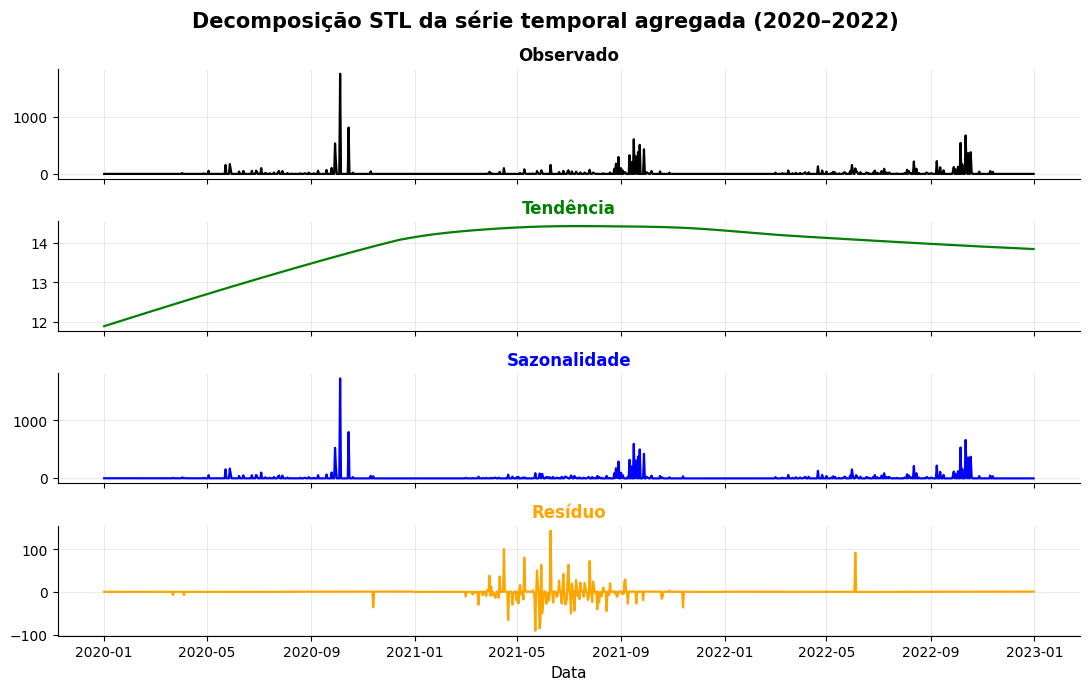

In [5]:
# ============================================
# CRIAÇÃO DA SÉRIE TEMPORAL CONTÍNUA (2020-2022)
# ============================================

full_series = pd.concat(daily_series.values())
full_series.index = pd.date_range("2020-01-01", periods=len(full_series), freq="D")

print(f"\n Série temporal contínua: {len(full_series)} dias")

# ============================================
# DECOMPOSIÇÃO STL DA SÉRIE AGREGADA (2020-2022)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL # STL é mais robusta a outliers e flexível que a decomposição clássica

print("\n" + "=" * 60)
print("DECOMPOSIÇÃO STL (2020-2022)")
print("=" * 60)

# STL com robustez a outliers
stl = STL(full_series, period=365, robust=True)
resultado = stl.fit()

# ----------------------------------------------------------------------------
# MÉTRICAS DA DECOMPOSIÇÃO
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("MÉTRICAS DA DECOMPOSIÇÃO")
print("=" * 60)

amp_saz = resultado.seasonal.max() - resultado.seasonal.min()
var_resid = resultado.resid.var()
var_trend = resultado.trend.max() - resultado.trend.min()
corr_obs_saz = full_series.corr(resultado.seasonal)

print(f"\nSazonalidade - amplitude: {amp_saz:.2f}")
print(f"Tendência - variação: {var_trend:.2f}")
print(f"Resíduo - variância: {var_resid:.2f}")

# ----------------------------------------------------------------------------
# CONTRIBUIÇÃO PARA A VARIÂNCIA TOTAL
# ----------------------------------------------------------------------------

var_total = full_series.var()
var_saz = resultado.seasonal.var()
var_trend = resultado.trend.var()
var_resid = resultado.resid.var()

print("\n" + "=" * 60)
print("CONTRIBUIÇÃO PARA A VARIÂNCIA TOTAL")
print("=" * 60)
print(f"Sazonalidade: {var_saz/var_total*100:.1f}%")
print(f"Tendência:    {var_trend/var_total*100:.1f}%")
print(f"Resíduo:      {var_resid/var_total*100:.1f}%")

# ----------------------------------------------------------------------------
# GRÁFICO
# ----------------------------------------------------------------------------

cores = {"Observado": "black", "Tendência": "green",
         "Sazonalidade": "blue", "Resíduo": "orange"}

fig, axes = plt.subplots(4, 1, figsize=(11, 7), sharex=True)

for ax, (titulo, serie) in zip(axes, [("Observado", full_series),
                                        ("Tendência", resultado.trend),
                                        ("Sazonalidade", resultado.seasonal),
                                        ("Resíduo", resultado.resid)]):
    ax.plot(serie, color=cores[titulo], linewidth=1.6)
    ax.set_title(titulo, fontsize=12, color=cores[titulo], fontweight="bold")
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xlabel("Data", fontsize=11)

plt.suptitle("Decomposição STL da série temporal agregada (2020–2022)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

A série apresenta comportamento irregular, com períodos de baixa ocorrência (primeiro semestre) e picos com muitas detecções (segundo semestre).

**Tendência**: A tendência permaneceu estável ao longo dos três anos analisados, com variação de apenas 2,5 detecções, indicando que não houve aumento ou redução importante no número de queimadas entre 2020 e 2022. As pequenas flutuações observadas estão associadas a diferenças interanuais na intensidade da estação seca.

**Sazonalidade**: A sazonalidade é o componente dominante da série, com amplitude de 1751 detecções e contribuição de 99,4% para a variância total. O padrão anual é bem definido, com pico no segundo semestre e vale no primeiro, refletindo o ciclo climático do Cerrado e a ocorrência de queimadas concentradas no final da estação seca.

**Resíduo**: O componente residual apresentou variância de aproximadamente 115,8 e respondeu por apenas 1,9% da variabilidade total da série. Os maiores resíduos correspondem a eventos pontuais que diferiram do comportamento sazonal predominante.


**6) Estatísticas (em busca do regime de queimadas)**

Com a série temporal decomposta, podemos aprofundar a análise do comportamento do fogo por meio de estatísticas e visualizações, identificando padrões sazonais, períodos críticos e a distribuição das queimadas ao longo dos anos.

Os códigos a seguir geram quatro gráficos complementares:

a) Regime mensal médio e sua variabilidade interanual (barras de desvio-padrão)

b) Padrão sazonal obtido pela decomposição da série, com destaque para o pico e a estação seca

c) Curva de detecções acumuladas, que exibe a concentração das detecções ao longo do ano e a janela crítica

d) Matriz anual de distribuição mensal das queimadas

**Estatísticas básicas**

In [6]:
MONTH_NAMES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

FIGSIZE = (10, 3)
LEGEND_FONTSIZE = 11

def calcular_indicadores_basicos(full_series):
    peak_day = full_series.idxmax()
    peak_value = full_series.max()
    monthly_totals = full_series.resample("ME").sum()
    peak_month = monthly_totals.idxmax()
    peak_month_value = monthly_totals.max()
    monthly_mean = full_series.groupby(full_series.index.month).mean()
    monthly_std = full_series.groupby(full_series.index.month).std()
    return {
        "peak_day": peak_day,
        "peak_value": peak_value,
        "monthly_totals": monthly_totals,
        "peak_month": peak_month,
        "peak_month_value": peak_month_value,
        "monthly_mean": monthly_mean,
        "monthly_std": monthly_std,
    }

ind = calcular_indicadores_basicos(full_series)

# ============================================
# PRINCIPAIS ESTATÍSTICAS DO REGIME DE FOGO
# ============================================

print(f"\nPico diário:")
print(f"  Data: {ind['peak_day'].strftime('%d/%m/%Y')}")
print(f"  Detecções: {int(ind['peak_value']):,}")

print(f"\nPico mensal:")
# CORREÇÃO: Converter para datetime antes de usar strftime
print(f"  Mês: {ind['peak_month'].to_pydatetime().strftime('%B/%Y')}")
print(f"  Detecções: {int(ind['peak_month_value']):,}")

print(f"\nTotal:")
print(f"  Dias com fogo: {(full_series > 0).sum():,}")
print(f"  Total de detecções: {int(full_series.sum()):,}")

print(f"\nMês de pico: {MONTH_NAMES[np.argmax(ind['monthly_mean'].values)]} "
      f"({ind['monthly_mean'].max():.1f} detecções/dia)")


Pico diário:
  Data: 05/10/2020
  Detecções: 1,750

Pico mensal:
  Mês: September/2021
  Detecções: 2,994

Total:
  Dias com fogo: 173
  Total de detecções: 14,809

Mês de pico: Out (55.9 detecções/dia)


**a) Regime mensal médio**

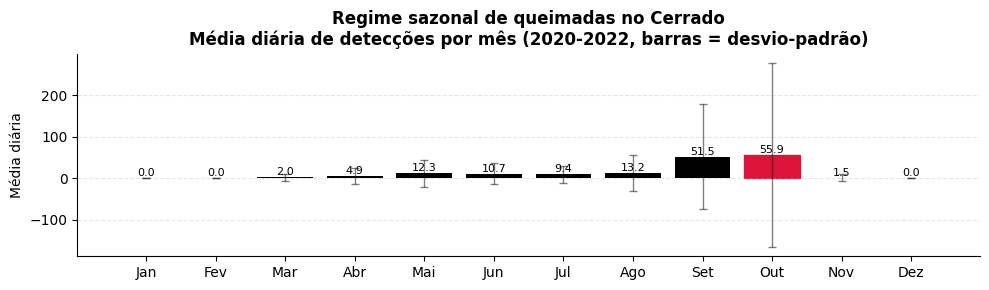

In [7]:
# ----------------------------------------------------------------------------
# FIGURA 1 - REGIME MENSAL
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(MONTH_NAMES, ind["monthly_mean"].values,
              yerr=ind["monthly_std"].values, capsize=3,
              color="black", error_kw={"alpha": 0.5, "linewidth": 1})
bars[np.argmax(ind["monthly_mean"].values)].set_color("crimson")

for bar, val in zip(bars, ind["monthly_mean"].values):
    ax.text(bar.get_x() + bar.get_width()/2, val, f"{val:.1f}",
            ha="center", va="bottom", fontsize=8)

ax.set_title("Regime sazonal de queimadas no Cerrado\n"
             "Média diária de detecções por mês (2020-2022, barras = desvio-padrão)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Média diária")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

O regime mensal revela uma sazonalidade bem definida, com queimadas concentradas entre maio e outubro. Os meses de setembro e outubro registram os maiores valores médios, com destaque para outubro (55,9 detecções/dia). De novembro a abril, as detecções são praticamente nulas.

**b) Padrão sazonal**

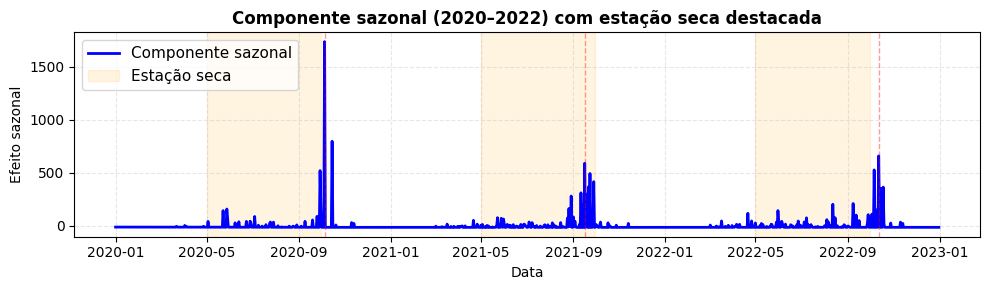

In [8]:
# ----------------------------------------------------------------------------
# FIGURA 2 - SAZONALIDADE (STL) - 3 ANOS COM ESTAÇÃO SECA
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

# Série completa da sazonalidade
ax.plot(resultado.seasonal.index, resultado.seasonal.values,
        color="blue", linewidth=2, label="Componente sazonal")

# Marca os picos anuais
for year in [2020, 2021, 2022]:
    mask = resultado.seasonal.index.year == year
    if mask.any():
        peak_date = resultado.seasonal[mask].idxmax()
        ax.axvline(peak_date, color="red", linestyle="--", alpha=0.4, linewidth=1)

# Destaca a estação seca em cada ano
for year in [2020, 2021, 2022]:
    start = pd.Timestamp(f"{year}-05-01")
    end = pd.Timestamp(f"{year}-09-30")
    ax.axvspan(start, end, alpha=0.12, color="orange", label="Estação seca" if year == 2020 else "")

ax.set_title("Componente sazonal (2020–2022) com estação seca destacada",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Data")
ax.set_ylabel("Efeito sazonal")
ax.grid(alpha=0.3, linestyle="--")
ax.legend(fontsize=LEGEND_FONTSIZE)
plt.tight_layout()
plt.show()

O componente sazonal ilustra o ciclo anual do fogo, com pico bem definido no dia 279 (início de outubro). A estação seca (maio a setembro) apresenta os maiores valores, enquanto a estação chuvosa (outubro a abril) mantém o efeito sazonal próximo de zero.

**c) Curva de detecções acumuladas**


 Janela crítica (80% das detecções):
  Início: Dia 150 (29/May)
  Fim:    Dia 289 (15/Oct)
  Duração: 140 dias


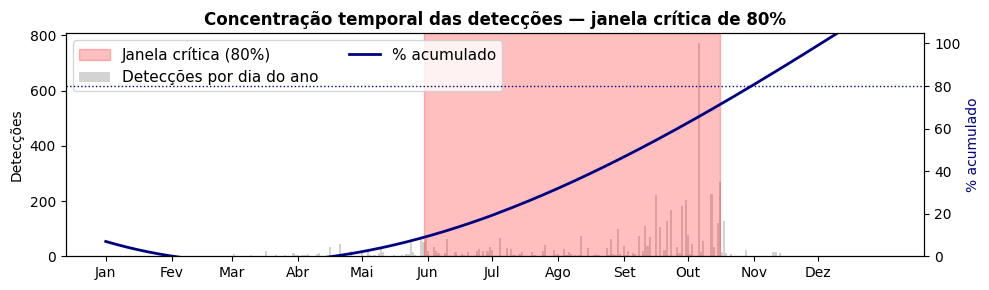

In [9]:
# ============================================
# PREPARAÇÃO PARA A CURVA DE DETECÇÕES ACUMULADAS
# ============================================

# Climatologia diária (média por dia do ano)
clim = full_series.groupby(full_series.index.dayofyear).mean()

# Janela crítica: 80% das detecções se concentram aqui
cum_sum = np.cumsum(clim.values)
cum_pct = cum_sum / cum_sum.max() * 100

# Encontrar os dias que correspondem a 10% e 90% do acumulado
window_start_doy = int(np.where(cum_pct >= 10)[0][0] + 1)
window_end_doy = int(np.where(cum_pct >= 90)[0][0] + 1)
wraps_year = False

# Converter dia do ano para data (usando datetime)
from datetime import datetime, timedelta
start_date = datetime(2020, 1, 1) + timedelta(days=window_start_doy - 1)
end_date = datetime(2020, 1, 1) + timedelta(days=window_end_doy - 1)

print(f"\n Janela crítica (80% das detecções):")
print(f"  Início: Dia {window_start_doy} ({start_date.strftime('%d/%b')})")
print(f"  Fim:    Dia {window_end_doy} ({end_date.strftime('%d/%b')})")
print(f"  Duração: {window_end_doy - window_start_doy + 1} dias")

# ----------------------------------------------------------------------------
# FIGURA 3 - CONCENTRAÇÃO TEMPORAL DAS DETECÇÕES (COM SUAVIZAÇÃO)
# ----------------------------------------------------------------------------

from scipy.signal import savgol_filter

fig, ax = plt.subplots(figsize=FIGSIZE)

doy = np.arange(1, len(clim.values) + 1)

# Barras da climatologia
ax.bar(doy, clim.values, color="lightgray", width=1.0, label="Detecções por dia do ano")

# Janela crítica
ax.axvspan(window_start_doy, window_end_doy if not wraps_year else 365,
           alpha=0.25, color="red", label="Janela crítica (80%)")
if wraps_year:
    ax.axvspan(1, window_end_doy, alpha=0.25, color="red")

# Curva acumulada suavizada
ax2 = ax.twinx()
cum_pct = np.cumsum(clim.values) / clim.values.sum() * 100

# Aplicar Savitzky-Golay
cum_pct_smooth = savgol_filter(cum_pct, window_length=365, polyorder=3)

ax2.plot(doy, cum_pct_smooth, color="navy", linewidth=2, label="% acumulado")
ax2.axhline(80, color="navy", linestyle=":", linewidth=1)
ax2.set_ylabel("% acumulado", color="navy")
ax2.set_ylim(0, 105)

ax.set_xticks([1,32,60,91,121,152,182,213,244,274,305,335])
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel("Detecções")
ax.set_title("Concentração temporal das detecções — janela crítica de 80%",
             fontsize=12, fontweight="bold")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=LEGEND_FONTSIZE, ncol=2, loc="upper left")
plt.tight_layout()
plt.show()

A curva suavizada das detecções acumuladas mostra que 80% das células queimadas se concentram em uma janela de aproximadamente 150 dias, entre julho e meados de outubro. Nesse período, o percentual acumulado salta de 20% para 80%, confirmando o caráter concentrado do regime de fogo no Cerrado. A janela crítica coincide com o final da estação seca e a transição para as chuvas, quando as condições são mais favoráveis à ocorrência de queimadas.

**d) Matriz anual**

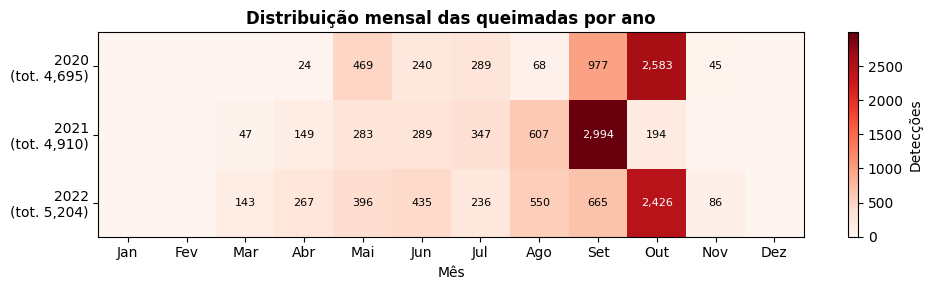

In [10]:
# ----------------------------------------------------------------------------
# FIGURA 4 - MATRIZ ANO x MÊS
# ----------------------------------------------------------------------------

monthly_matrix = full_series.resample("ME").sum().to_frame("fogo")
monthly_matrix["ano"] = monthly_matrix.index.year
monthly_matrix["mês"] = monthly_matrix.index.month
heatmap = monthly_matrix.pivot(index="ano", columns="mês", values="fogo")

fig, ax = plt.subplots(figsize=FIGSIZE)
im = ax.imshow(heatmap.values, aspect="auto", cmap="Reds")

ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_NAMES)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels([f"{y}\n(tot. {int(heatmap.loc[y].sum()):,})" for y in heatmap.index])
ax.set_title("Distribuição mensal das queimadas por ano", fontsize=12, fontweight="bold")
ax.set_xlabel("Mês")

vmax = heatmap.max().max()
for i in range(len(heatmap.index)):
    for j in range(12):
        val = heatmap.iloc[i, j]
        if pd.notna(val) and val > 0:
            ax.text(j, i, f"{int(val):,}", ha="center", va="center", fontsize=8,
                    color="white" if val > vmax/2 else "black")

plt.colorbar(im, ax=ax, label="Detecções")
plt.tight_layout()
plt.show()

A matriz anual confirma a consistência interanual do padrão: em todos os anos analisados, as queimadas se concentram entre agosto e outubro, que juntos responderam por 56% (2020), 64% (2021) e 62% (2022) das detecções. Os totais anuais variaram pouco (4.695 a 5.204 detecções), sugerindo que o regime de fogo na área de estudo se manteve relativamente estável nesses meses ao longo dos três anos.

<small>O DeepSeek foi utilizado na padronização dos códigos.</small>

### **E o que a transformação de séries temporais revela sobre o regime do fogo?**

Ao longo deste *notebook*, vimos que a transformação de séries temporais vai além de uma etapa de processamento: ela permite revelar padrões em dados inicialmente inadequados.

Partindo de registros esparsos (como células, pixels ou pontos vetoriais que contenham datas anotadas) e valores *None*, podemos construir uma série temporal contínua capaz de descrever, ou ajudar a entender, dinâmicas de queimadas em determinada área de estudo. Neste exemplo, utilizamos o *dataset* que cobre o Parque Nacional da Chapada dos Veadeiros, em Goiás, com o objetivo de explorarmos o padrão temporal de queimadas entre 2020 e 2022.

Link para o dataset: https://doi.org/10.57760/sciencedb.14040

**Bio**

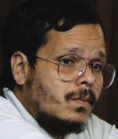

Alisson de Oliveira é Bacharel em Gestão e Análise Ambiental pela Universidade Federal de São Carlos (UFSCar) desde 2021 e Mestre em Sensoriamento Remoto pelo Instituto Nacional de Pesquisas Espaciais (INPE) desde 2024. Atualmente está no terceiro ano do doutorando em Sensoriamento Remoto no INPE, onde desenvolve pesquisas voltadas à análise ambiental utilizando dados de sensoriamento remoto e *machine learning*, como foco na utilização dos satélites brasileiros CBERS-4, CBERS-4A e AMAZONIA-1